# Market-implied stock price PDFs: risk-neutral and physical

Option prices embed information about the markets expectation of future performance of the underlying asset.
The set of European option prices across strikes for a given maturity $T$ implies a risk-neutral probability density function (details below) of the price $S_T$ of the underlying asset at the maturity.

This density reflects the distribution consistent with current option prices under the pricing measure that discounts payoffs at the risk-free rate.
It also reflects both how the market expects the underlying to move (although it is important to note that the pdf we obtain is NOT simply the market's prediction of where the stock is likely to move), as well as how the market prices risk across the various outcomes.

This project uses several years of daily SPX option chain data to extract the market-implied risk-neutral pdfs for options with 1 day maturities, 7 day maturities, and 28 day maturities.
Using the Breeden-Litzenberger relation, which says that the implied pdf is given by the second partial derivative of price at maturity with respect to strike:
$$ f_Q(K) = e^{rT} \frac{\partial^2 C(K, T)}{\partial K^2},$$
we numerically recover the pdf.
Since strikes come in discrete increments, we require some numerical techniques to interpolate.
We also need to smooth the data enough to take a second derivative.

I then discuss and compare ways of recovering the real-world probability distribution from the risk-neutral one.

There are two main goals of this project:
1. Compare the risk-neutral pdf to the realized price distribution.
2. Test a simple way of estimating the real-world density function from the risk-neutral density.

I also have the goal of giving exposition of the theory and background needed to understand this topic so that a wider audience may find it useful and engaging.

# TODO: I am making some updates before sending in the next round of applications
- see TODOs in the text
- maybe we can do better forecast evalution?
- incorporate actual interest rates / risk free rates
- the power-utility section uses some $\gamma = 4$ 
- think about possible extensions:
    - Can a stable pricing kernel learned from historical option-implied distributions transform future risk-neutral densities into better-calibrated physical distributions?

## Notes
- be careful wwith one-sided quotes
- we use Black's formula rather than the standard Black-Scholes formula. They are closely related but we'll calculate forwards ourselves using put-call parity and this way we don't have to estimate expectations about dividends
- note that the convention for risk-free rate in the black's formula implementation currently assumes a continuously compounded annual rate
- TOOD: implement vectorized inversion in the black-scholes code with `from scipy.optimize import elementwise`; then use `elementwise.find_root`
- TODO: unit tests for everything in implied_stock_distributions
- I'm not terribly happy with the smoothing that's going on, I think a parametric model might perform better
    - the good news is that we have a nice framework for testing the differences; future work?
    - see [here](https://www.nber.org/papers/w8944) and [here](https://edoc.hu-berlin.de/server/api/core/bitstreams/4af0fb58-fda0-4e91-8fb2-fa451714a275/content) for further reading.

# possible extensions

## Can a stable pricing kernel learned from historical option-implied distributions transform future risk-neutral densities into better-calibrated physical distributions?

Under CRRA utility,

$$  $$

## Part 1: Implied risk-neutral distributions

### Theoretical Background

#### **Put-Call parity**

Put-call parity is a fundamental no-arbitrage relationship between European call and put options with the same underlying data: asset, strike price, and terminal date.
It follows from the simple fact that two portfolios with identical terminal payoffs must have the same value today.
Consider a European call and put with strike $K$.
If one buys the call and sells the put, they make money when the terminal price $S_T$ is above $K$, and lose money when it is below $K$.
That is, this portfolio is the same as a forward contract to buy the stock for $K$ at the terminal time $T$.
The terminal payoff is
$$ C_T - P_T = \max(S_T - K, 0) - \max(K - S_T, 0) = S_T - K. $$
Since these two portfolios have the same terminal price, they must also have the same price at $t=0$.
With a continuously compounded risk-free interest rate $r$ (and a non-dividend paying asset), the present value of $K$ can be found by discounting back by time-distance $T$: it is $K e^{-rT}$.
So
$$ C_0 - P_0 = S_0 - Ke^{-rT}. $$
We call $e^{-rT}$ the *discount factor* from time $T$.
Let $F_{0,T}$ denote the forward price observed at time $0$ for delivery at time $T$.
For a non-dividend paying asset,
$F_{0,T} = S_0 e^{rT}$, meaning that $S_0 = e^{-rT} F_{0,T}$.
We can put this into the put-call parity formula to get
$$ C_0 - P_0 = e^{-rT} (F_{0,T} - K). $$
Observe that across an option chain, we have multiple call and put prices for different strikes, so that
$$ C_0(K) - P_0(K) = e^{-rT} (F_{0,T} - K). $$
Now we can fit a line to $C-P$ against $K$; the slope of this line will be the discount factor (from which we can solve for interest rate), and the intercept will be the discount factor times the forward price, from which we can solve for the forward price.
This is implemented in `implied_probability_distributions/pricing.py`.

#### **Risk-neutral probability measure**

To understand the risk-neutral probability measure, we start with almost the simplest possible case: a market that will evolve over only one timestep.
Time $t=0$ is the starting point, and time $t=1$ is the second and final step in the evolution of the market.
At $t=1$, the world can be in one of $n$ possible states
$$ \Omega = \{\omega_1, \dots, \omega_n\}$$
with real-world probabilities $P(\omega_i) \geq 0$, $\sum_i P(\omega_i) = 1$.
This function $P$ that describes these probabilities is called the *real-world probability measure*, and of course when it appears in real scenarios it is essentially unknowable.

Suppose our market has one traded asset $S$, worth $\$100$ at $t=0$ and a risk-free account with interest rate $r$.
Suppose also that for some set $U \subset \Omega$ of states of the world at $t=1$, $S$ will go up to $S_0 \cdot u$, and for the complement $D = \Omega \setminus U$, $S$ will go down to $S_0 \cdot d$, for some factors $u,d$ with $0 < d < 1 < u$.

There is some real-world probability $P(U)$ that $S$ will go up, and some real probability $P(D)$ that $S$ will go down.
These probabilities are of course unknowable, but it turns out that they are not necessary for the risk-neutral probability measure.

Now if $e^r < d$, then there is an arbitrage scheme: borrow $S_0$ dollars at $t=0$ and buy one unit of $S$.
Then regardless of whether the asset goes up or down, the value at $t=1$ would be higher than $S_0 e^r$, which is the amount one would owe at the end.

Similarly, if $e^r > u$, one could short the stock and invest the proceeds into the risk-free account, and have a guaranteed profit.

The *no-arbitrage condition* $d \leq e^r \leq u$ ensures that there is no arbitrage in this simple model.
These inequalities also imply the following bounds:
$$
\begin{aligned}
0 &\leq \frac{e^r - d}{u - d} \leq 1 \\
0 &\leq \frac{u - e^r}{u - d} \leq 1.
\end{aligned}
$$
Note also that
$$
\frac{e^r - d}{u - d} + \frac{u - e^r}{u - d} = 1.
$$
Now if we assign $Q(U) = \frac{e^r - d}{u - d}$, and $Q(D) = \frac{u - e^r}{u - d}$, then $Q$ defines a probability measure on $\{\varnothing, U, D, \Omega \} \subset \mathcal P(\Omega)$.
This is the risk-neutral probability measure for this toy model, which we have just derived without any reference to the real-world probabilities of any events occurring.

Moreover, it is not too hard to calculate (see [here](https://quant.stackexchange.com/questions/55239/explaining-the-risk-neutral-measure), for example) that $S_0 = e^{-r} \mathbb E[S_1]$.

The dynamics of the real market are of course more complicated, but the idea of the risk-neutral probability measure is the same:
it is the probability measure under which all (discounted) tradable asset prices are martingales.
Another way to think about this is that if $p(x)$ represents the physical probability predicted by the market, i.e. how likely some event is, then the risk-neutral probability $q(x)$ describes how highly does the market price a claim that pays in this outcome.
They aren't the same because investors care more about a dollar received in a disastrous state than one received in a booming state.


#### **The Breeden-Litzenberger Formula**

Recall that the fair value of a call option with time $\tau$ until expiry is the present value of the expected payoff.
If $f_Q$ denotes the PDF of the stock prices $S_T$ of some stock $S$ at time $T$ (with respect to the risk-neutral measure $Q$), this is
$$
\begin{aligned}
C(K, \tau) &= e^{-rt} \mathbb E_Q(\max\{S_T - K, 0\}) \\
&= e^{-rt} \int_0^\infty \max\{x - K, 0\} f_Q(x) \, d x \\
&= e^{-rt} \int_K^\infty (x - K) f(x) \, dx.
\end{aligned}
$$
To derive the Breeden-Litzenberger formula, we just need to invert this to find $f$ as a function of $C$.
Taking the partial derivative with respect to $K$ gives
$$
\begin{aligned}
\frac{\partial C}{\partial K} &= - e^{-rt} \int_{K}^\infty f(x) \, dx \\
&= e^{-rt} \left( \int_{-\infty}^K f(x) \, dx - 1 \right),
\end{aligned}
$$
where in the second step we use the fact that $\int_{\mathbb R} f(x) \, dx = 1$.
But now we can find $f$ by taking one more derivative.
Doing this and rearranging, we see that
$$f(K) = e^{rt} \frac{\partial^2 C}{\partial K^2}.$$


#### **Constructing a physical density from the risk-neutral one**

TODO

### Implementation

We begin by using the Breeden–Litzenberger formula to estimate risk-neutral probability densities from market option prices.

#### The data

Cleaning and validating the raw data required substantial preprocessing. The code and further explanation are provided in `data/processing.ipynb`.

The final dataset contains option chains for the years listed in `valid_years` below, with maturities closest to 30, 60, and 90 calendar days. Although other maturities are available, these three provide sufficient coverage for the methods explored here while keeping the analysis manageable.
I have implemented a catalogue for the options chain data in `/implied_stock_distributions/data_access.py`.
This is for two reasons:
- My computer won't hold all the data at once in memory anyway, so I need a way to iterate through all the chains that doesn't involve loading them all at once.
- The data is organized primarily by quote time, and we would like to have a convenient way to pick out all the rows corresponding to one chain.


First I'll import the data and get it into the dataframes that I want.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

from implied_stock_distributions.black_scholes import *     # utility functions related to the Black-Scholes formula
from implied_stock_distributions.forwards import estimate_forward_and_rate

from scipy.interpolate import CubicSpline # for cubic interpolation with smoothing
from scipy.interpolate import make_splrep

In [2]:
from implied_stock_distributions.data_access import discover_data_files, load_random_chain

data_files_by_year, data_files = discover_data_files()
# print(data_files_by_year)

/home/steven/github/implied-stock-distributions/implied_stock_distributions
/home/steven/github/implied-stock-distributions


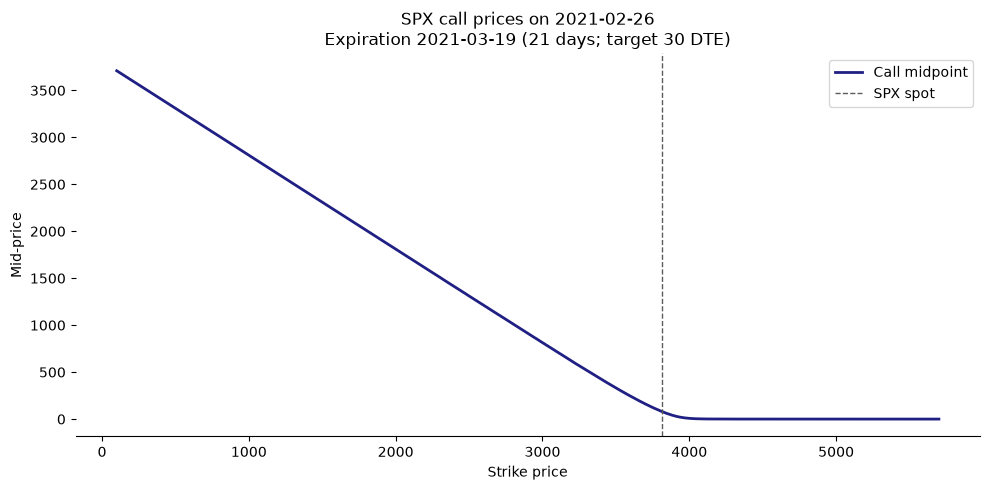

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from implied_stock_distributions.data_access import (
    load_chain,
    load_chain_catalog,
    load_random_chain
)



def plot_call_chain(
    info: pd.Series,
    chain: pd.DataFrame,
):
    """Plot call-option mid-prices for one chain."""

    calls = (
        chain.loc[chain["put_call"].eq("call")]
        .sort_values("strike_price")
        .copy()
    )

    if calls.empty:
        raise ValueError("The selected chain contains no calls.")

    # Calculate the midpoint if it was not stored during preprocessing.
    if "mid_price" not in calls.columns:
        calls["mid_price"] = (
            calls["bid_price"] + calls["ask_price"]
        ) / 2

    data_date = pd.Timestamp(info["data_date"])
    expiration_date = pd.Timestamp(info["expiration_date"])
    actual_dte = (expiration_date - data_date).days
    spot = calls["underlying_price"].median()

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        calls["strike_price"],
        calls["mid_price"],
        color="#1F1F84",
        linewidth=2,
        label="Call midpoint",
    )

    ax.axvline(
        spot,
        color="#5C5C5C",
        linestyle="--",
        linewidth=1,
        label="SPX spot",
    )

    ax.set_title(
        f"SPX call prices on {data_date.date()}\n"
        f"Expiration {expiration_date.date()} "
        f"({actual_dte} days; target "
        f"{info['target_dte_days']} DTE)"
    )
    ax.set_xlabel("Strike price")
    ax.set_ylabel("Mid-price")

    for spine in ("right", "left", "top"):
        ax.spines[spine].set_visible(False)

    ax.legend()
    fig.tight_layout()

    return fig, ax


catalog = load_chain_catalog()

info, chain = load_random_chain(
    catalog,
    target_dte_days=30,
    random_state=67
)

fig, ax = plot_call_chain(info, chain)

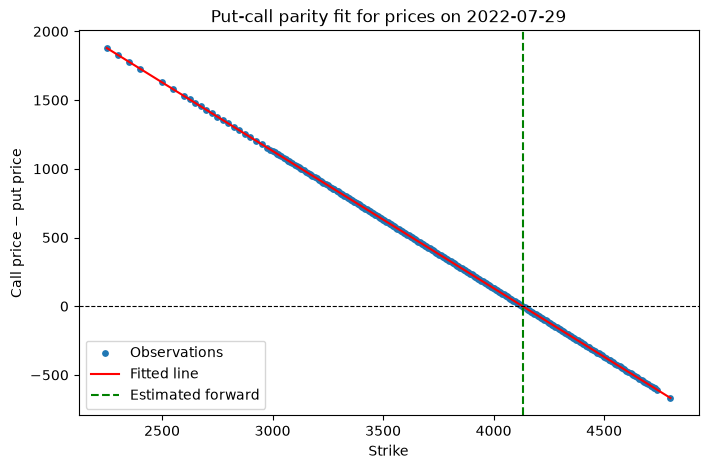

In [4]:
# linear regression to fit a line to C - P as a function of strike

from implied_stock_distributions.forwards import estimate_forward_and_rate



info, chain = load_random_chain(
    catalog,
    target_dte_days=30,
)

# for the chain we selected, use linear regression to estimate the discount factor and forward
estimates, pairs = estimate_forward_and_rate(chain)


# plot the fit
plt.figure(figsize=(8, 5))

plt.scatter(
    pairs["strike_price"],
    pairs["call_minus_put"],
    s=15,
    label="Observations",
)

plt.plot(
    pairs["strike_price"],
    pairs["fitted_call_minus_put"],
    color="red",
    label="Fitted line",
)

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)

plt.axvline(
    estimates["forward"],
    color="green",
    linestyle="--",
    label="Estimated forward",
)

plt.xlabel("Strike")
plt.ylabel("Call price − put price")
plt.title(f"Put-call parity fit for prices on {info['data_date'].date()}")
plt.legend()
plt.show()

Since the scale of this plot is large, this curve may appear smooth, but it is likely that it contains small irregularities.
Recall that extracting the implied probability density via the Breeden-Litzenberger formula requires computing second derivatives of option prices with respect to strike, which will greatly amplify any irregularities.
Due to this, we need to smooth this curve.
Also due to this, we should not try interpolating/smoothing directly on this data; the second derivative is too sensitive for the smoothing we do to be sufficient.

A more robust approach is to convert the prices to implied volatilities using Black-Scholes, perform the smoothing in volatility space, and then convert back to prices.
In fact, we'll do one more step: after we obtain implied volatility as a function of strike price, we'll convert it to a function of log-moneyness (roughly, this is just the log of the strike price), *then* do the smoothing, and then convert back.
$$ k = \log\left(\frac{K}{F}\right), $$

The example below illustrates the problem with trying to smooth prices directly.


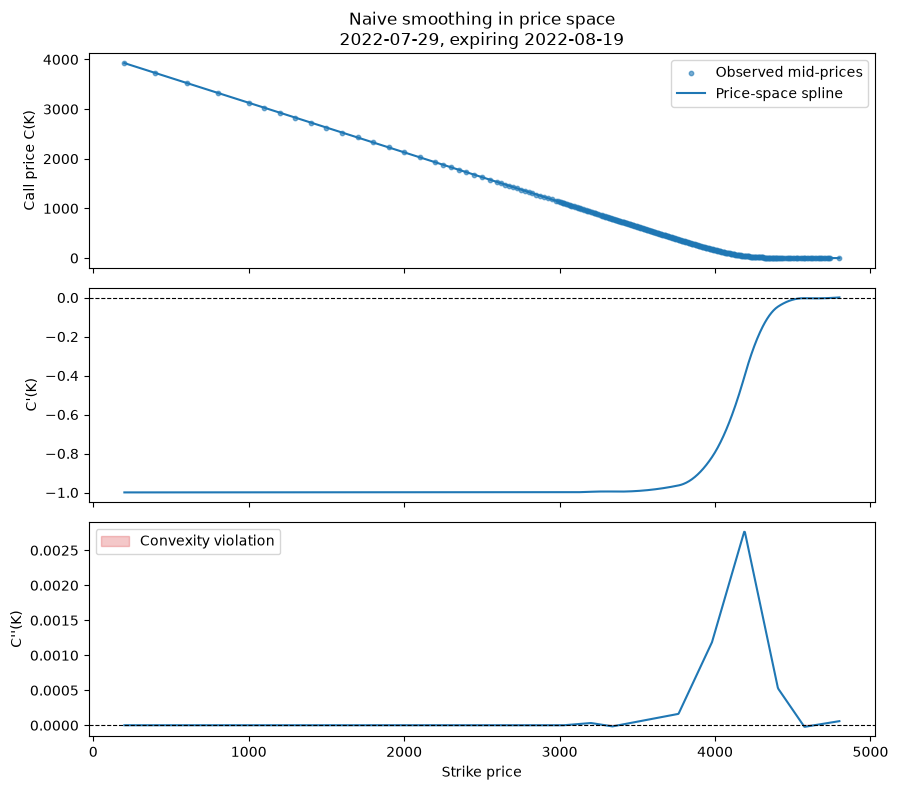

In [5]:
from scipy.interpolate import make_splrep

# Keep only calls from the selected chain.
calls = chain.loc[chain["put_call"].eq("call")].copy()


# Optional: use only two-sided quotes for a fairer illustration
if "quote_is_two_sided" in calls.columns:
    calls = calls.loc[
        calls["quote_is_two_sided"].fillna(False)
    ]

calls = calls.loc[
    np.isfinite(calls["strike_price"])
    & np.isfinite(calls["mid_price"])
].sort_values("strike_price")

if calls["strike_price"].duplicated().any():
    raise ValueError("The chain contains duplicate call strikes.")

if len(calls) < 4:
    raise ValueError("At least four call prices are required.")

K = calls["strike_price"].to_numpy(dtype=float)
C_mid = calls["mid_price"].to_numpy(dtype=float)

# Arbitrary smoothing choice for this illustrative example
smoothing = 0.035 * len(K)

price_spline = make_splrep(
    K,
    C_mid,
    k=3,
    s=smoothing,
)

K_fine = np.linspace(K.min(), K.max(), 1000)
C_smooth = price_spline(K_fine)

# Differentiate the fitted spline itself
dC_dK = price_spline.derivative(1)(K_fine)
d2C_dK2 = price_spline.derivative(2)(K_fine)

data_date = pd.Timestamp(info["data_date"]).date()
expiration_date = pd.Timestamp(info["expiration_date"]).date()

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 8),
    sharex=True,
)

axes[0].scatter(
    K,
    C_mid,
    s=10,
    alpha=0.6,
    label="Observed mid-prices",
)
axes[0].plot(
    K_fine,
    C_smooth,
    linewidth=1.5,
    label="Price-space spline",
)
axes[0].set_ylabel(r"Call price C(K)")
axes[0].legend()
axes[0].set_title(
    "Naive smoothing in price space\n"
    f"{data_date}, expiring {expiration_date}"
)

axes[1].plot(K_fine, dC_dK, linewidth=1.5)
axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=0.8,
)
axes[1].set_ylabel(r"C'(K)")

axes[2].plot(K_fine, d2C_dK2, linewidth=1.5)
axes[2].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=0.8,
)

# Highlight regions that violate call-price convexity
axes[2].fill_between(
    K_fine,
    d2C_dK2,
    0,
    where=d2C_dK2 < 0,
    color="tab:red",
    alpha=0.25,
    label="Convexity violation",
)

axes[2].set_ylabel(r"C''(K)")
axes[2].set_xlabel("Strike price")
axes[2].legend()

fig.tight_layout()
plt.show()

In the following cell, we define functions that convert the price data to implied volatility, perform a smoothed interpolation, convert back to price, and then compute the second derivative.

data_date                                        2005-05-18 00:00:00
expiration_date                                  2005-07-16 00:00:00
target_dte_days                                                   60
parquet_path       /home/steven/github/implied-stock-distribution...
Name: 161, dtype: object


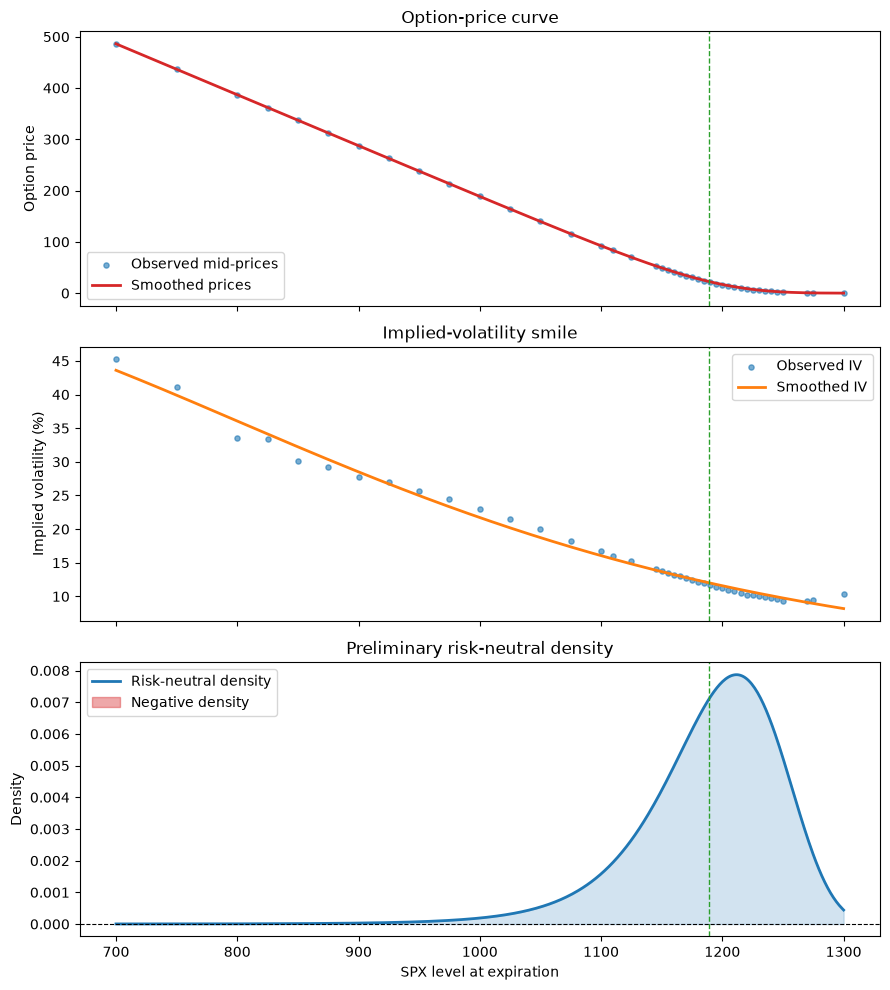

In [7]:

from implied_stock_distributions.smoothing import create_density_from_chain, compute_implied_vols

# parity_estimates, parity_pairs = estimate_forward_and_rate(
#     chain,
#     use_spread_weights=False,
# )

# forward = parity_estimates["forward"]
# risk_free_rate = parity_estimates["risk_free_rate"]

info, chain = load_random_chain(
    catalog,
    target_dte_days=60,
)

estimates, pairs = estimate_forward_and_rate(chain)
forward = estimates["forward"]
risk_free_rate = estimates["risk_free_rate"]

strike_grid, smooth_prices, density, iv_curve = (
    create_density_from_chain(
        chain=chain,
        forward=forward,
        risk_free_rate=risk_free_rate,
        option_type="call",
        smoothing_factor=.15
    )
)

# plt.plot(strike_grid, smooth_prices)



option_type = "call"

forward = estimates["forward"]
risk_free_rate = estimates["risk_free_rate"]
time_to_expiry = float(
    chain["time_to_expiry_years"].iloc[0]
)

quotes = chain.loc[
    chain["put_call"].eq(option_type)
].copy()

if "quote_is_two_sided" in quotes.columns:
    quotes = quotes.loc[
        quotes["quote_is_two_sided"].fillna(False)
    ]

if "mid_price" not in quotes.columns:
    quotes["mid_price"] = (
        quotes["bid_price"] + quotes["ask_price"]
    ) / 2

# Calculate the unsmoothed IV observations for comparison.
observed_strikes, observed_iv = compute_implied_vols(
    strikes=quotes["strike_price"],
    prices=quotes["mid_price"],
    forward=forward,
    time_to_expiry=time_to_expiry,
    option_type=option_type,
    risk_free_rate=risk_free_rate,
)

fitted_iv = iv_curve(strike_grid)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 10),
    sharex=True,
)

# Observed and reconstructed prices
axes[0].scatter(
    quotes["strike_price"],
    quotes["mid_price"],
    s=14,
    alpha=0.6,
    label="Observed mid-prices",
)
axes[0].plot(
    strike_grid,
    smooth_prices,
    color="tab:red",
    linewidth=2,
    label="Smoothed prices",
)
axes[0].set_ylabel("Option price")
axes[0].set_title("Option-price curve")
axes[0].legend()

# Observed and fitted implied volatility
axes[1].scatter(
    observed_strikes,
    100 * observed_iv,
    s=14,
    alpha=0.6,
    label="Observed IV",
)
axes[1].plot(
    strike_grid,
    100 * fitted_iv,
    color="tab:orange",
    linewidth=2,
    label="Smoothed IV",
)
axes[1].set_ylabel("Implied volatility (%)")
axes[1].set_title("Implied-volatility smile")
axes[1].legend()

# Preliminary risk-neutral density
axes[2].plot(
    strike_grid,
    density,
    color="tab:blue",
    linewidth=2,
    label="Risk-neutral density",
)
axes[2].fill_between(
    strike_grid,
    density,
    0,
    where=density >= 0,
    color="tab:blue",
    alpha=0.2,
)
axes[2].fill_between(
    strike_grid,
    density,
    0,
    where=density < 0,
    color="tab:red",
    alpha=0.4,
    label="Negative density",
)
axes[2].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=0.8,
)
axes[2].set_xlabel("SPX level at expiration")
axes[2].set_ylabel("Density")
axes[2].set_title("Preliminary risk-neutral density")
axes[2].legend()

# Show the estimated forward on every graph.
for ax in axes:
    ax.axvline(
        forward,
        color="tab:green",
        linestyle="--",
        linewidth=1,
    )
print(info)

fig.tight_layout()
plt.show()


## Comparing to market data

Now that I have a way to generate predictions from historical data, I can compare to see what the actual price of the underlying was on the day of expiry.
The method that I'll use to evaluate the accuracy of the predictions is called the **continuous ranked probability score.**
It is defined by
$$ C(D, y) = \int_{\mathbb R} (F_D(x) - \mathbf 1_{x \geq y})^2 \, dx, $$
where
- $F_D$ is the cumulative distribution function of the forecasted distribution $D$,
- $\mathbf 1_{x \geq y}$ is the indicator function, which is 1 if $x \geq y$ and 0 otherwise, and
- $y \in \mathbb R$ is the observation.

I will evaluate this integral numerically to assign a score to the predicted pdfs.
It is not hard to see by looking at the definition that a lower score is better, with 0 being the lowest possible score, which can only be achieved by the distribution that assigns probability 1 to the observed outcome, and 0 to all other outcomes.
In general, this score rewards some combination of both precision and accuracy.



We'll start by downloading the SPX data for the same range that we have option data.

Now we implement the CRPS function described above, and a function that will calculate the CRPS given a dataframe of option data.

In [ ]:

earliest_day = pd.to_datetime(spx_df['quote_unix'].min(), unit="s")
latest_day = pd.to_datetime(spx_df['expire_unix'].max(), unit="s")

spx_data = yf.download("^SPX", start=earliest_day, end=latest_day, auto_adjust=True)
display(spx_data)

from scipy.integrate import cumulative_trapezoid


def crps_from_density_grid(
    strike_grid,
    density,
    realized_value,
    normalize=False,
    negative_tolerance=1e-10,
):
    """
    Calculate CRPS from a density evaluated on a strike grid.

    If normalize=True, the density is normalized over the supplied grid.
    This should only be used as an exploratory approximation when the grid
    does not contain the complete distribution.
    """

    strike_grid = np.asarray(strike_grid, dtype=float)
    density = np.asarray(density, dtype=float)

    if strike_grid.shape != density.shape:
        raise ValueError(
            "strike_grid and density must have the same shape."
        )

    valid = (
        np.isfinite(strike_grid)
        & np.isfinite(density)
    )
    strike_grid = strike_grid[valid]
    density = density[valid]

    order = np.argsort(strike_grid)
    strike_grid = strike_grid[order]
    density = density[order]

    if np.any(np.diff(strike_grid) <= 0):
        raise ValueError("Strike grid must be strictly increasing.")

    if not (
        strike_grid.min()
        <= realized_value
        <= strike_grid.max()
    ):
        raise ValueError(
            "The realized value is outside the density grid."
        )

    if density.min() < -negative_tolerance:
        raise ValueError(
            "Density contains meaningful negative values."
        )

    # Remove only negligible floating-point negatives.
    density = np.maximum(density, 0)

    mass = np.trapezoid(density, strike_grid)

    if mass <= 0:
        raise ValueError("Density has non-positive mass.")

    if normalize:
        density = density / mass
    elif not np.isclose(mass, 1, atol=0.02):
        raise ValueError(
            f"Density mass is {mass:.4f}, not approximately one."
        )

    cdf = cumulative_trapezoid(
        density,
        strike_grid,
        initial=0,
    )
    cdf = np.clip(cdf, 0, 1)

    indicator = (
        strike_grid >= realized_value
    ).astype(float)

    return float(
        np.trapezoid(
            (cdf - indicator) ** 2,
            strike_grid,
        )
    )


def evaluate_risk_neutral_prediction_from_chain(
    chain,
    realized_values,
    option_type="call",
    normalize_density=False,
):
    """
    Construct and evaluate the risk-neutral density for one chain.

    realized_values should be a Series indexed by expiration date.
    """

    expiry_dates = (
        chain["expiration_date"]
        .dropna()
        .drop_duplicates()
    )

    if len(expiry_dates) != 1:
        raise ValueError(
            "Expected exactly one expiration date."
        )

    expiry_date = pd.Timestamp(
        expiry_dates.iloc[0]
    ).normalize()

    if expiry_date not in realized_values.index:
        raise KeyError(
            f"No realized value found for {expiry_date.date()}."
        )

    realized_value = float(
        realized_values.loc[expiry_date]
    )

    estimates, parity_pairs = estimate_forward_and_rate(
        chain,
        use_spread_weights=False,
    )

    strike_grid, smooth_prices, density, iv_curve = (
        create_density_from_chain(
            chain=chain,
            forward=estimates["forward"],
            risk_free_rate=estimates["risk_free_rate"],
            option_type=option_type,
        )
    )

    score = crps_from_density_grid(
        strike_grid=strike_grid,
        density=density,
        realized_value=realized_value,
        normalize=normalize_density,
    )

    return {
        "crps": score,
        "relative_crps": score / estimates["forward"], # the index level changes substantially from 2005 to 2024, so we want to keep a relative score
        "realized_value": realized_value,
        "forward": estimates["forward"],
        "risk_free_rate": estimates["risk_free_rate"],
        "density_mass": np.trapezoid(
            density,
            strike_grid,
        ),
    }

Before we do the calculation, we can demonstrated a few graphs of pdfs together with the actual value of the underlying at expiration of the options from which we derive the pdf, as well as the CRPS score of the prediction and outcome.

In [ ]:
for _ in range(3):
    dfs = {
        "1DTE": spx_1dte_dfs,
        "7DTE": spx_7dte_dfs,
        "28DTE": spx_28dte_dfs,
    }

    df_type = random.choice(["1DTE", "7DTE", "28DTE"])
    df = dfs[df_type][random.randint(0, len(dfs[df_type]))].copy()

    expiry_date = str(pd.to_datetime(df['expire_unix'].iloc[0], unit="s").date())
    spx_price_on_expiry_date = spx_data.loc[expiry_date, "Close"].iloc[0]

    strikes_fine, bs_prices_fine, f_2 = create_pdf_from_df(df, option_type)

    plt.plot(strikes_fine, f_2(strikes_fine), label="pdf")
    plt.vlines(spx_price_on_expiry_date, ymin=0, ymax=f_2(strikes_fine).max()*1.05, color="#333333", linestyle="--", label="Observed price")
    plt.title(f"pdf and observed price for a {df_type} option expiring on {expiry_date}")
    plt.legend()
    plt.show()

In [ ]:

print("Calculating CRPS scores...")
for df_type in [spx_1dte_dfs, spx_7dte_dfs, spx_28dte_dfs]:
    c = 0
    p = 0
    for df in df_type:
        
        call_score = evaluate_rn_option_prediction_from_df(df, 'call')
        put_score = evaluate_rn_option_prediction_from_df(df, 'put')
        c += call_score
        p += put_score

    print(f"Average CRPS for {int(df_type[0]['dte'].iloc[0])} DTE calls: {c / len( df_type ) :.2f}")
    print(f"Average CRPS for {int(df_type[0]['dte'].iloc[0])} DTE puts: {p / len( df_type ) :.2f}")


By themselves these numbers are too abstract to be useful; it isn't clear what constitutes a good or bad score.
We can get some intuition for the meaning of the scores with the following code.
This code calculates the hypothetical scenario in which the stock price at the expiry of the option turns out to be the price that maximizes the density function for the market-implied probability distribution.

We'll also find these numbers useful for comparison in the next section where we test a method of converting the risk-neutral density to real-world density.

In [ ]:
print("Calculating CRPS scores in the hypothetical case that all predictions turn out to be correct...")
for df_type in [spx_1dte_dfs, spx_7dte_dfs, spx_28dte_dfs]:
    s = 0
    for df in df_type:
        expiry_date = str(pd.to_datetime(df['expire_unix'].iloc[0], unit="s").date())

        strikes_fine, bs_prices_fine, f_2 = create_pdf_from_df(df, 'call')
        densities = f_2(strikes_fine)
        max_idx = np.argmax(densities)
        max_probability_price = strikes_fine[max_idx] 
        score = crps(f_2, max_probability_price, strikes_fine.min(), strikes_fine.max())

        s += score                             

    print(f"Average CRPS for {int(df_type[0]['dte'].iloc[0])} DTE calls if all predictions were correct: {s / len( df_type ) :.2f}")

# Part 2: converting the risk-neutral density to a real-world density

See section 16.9 of the book Asset Price Dynamics, Volatility, and Prediction by Stephen Taylor.

As discussed before, the density that we are extracting from the option prices is not just purely the market's prediction of where the stock is likely to move.
So far I have obtained a density $f_Q$ for the risk-neutral probability measure $Q$, and I would like to convert this to a density $f_P$ for the real-world probability measure $P$.
In general there is not an obvious way to do this.

Recall our previous calculation that
$$
\begin{aligned}
C(K, T) &= e^{-rT} \mathbb E_Q(\max\{S_T - K, 0\}) \\
&= e^{-rT} \int_0^\infty \max\{x - K, 0\} f_Q(x) \, d x
\end{aligned}
$$
We can continue this:
$$
\begin{aligned}
\qquad \qquad \qquad \quad &= e^{-rT} \int_0^\infty \max\{x - K, 0\} \frac{f_Q(x)}{f_P(x)} f_P(x) \, dx \\
&= \mathbb E_P[ \max\{S_T - K, 0\} \cdot m(S_T) ],
\end{aligned}
$$
where $m(S_T)$ is a random variable called the *stochastic discount factor*, and is defined by the equation above, so that
$$
m(S_T) = e^{-r T} \frac{f_Q(S_T)}{f_P(S_T)}.
$$
Under some assumptions, one can related the stochastic discount factor to the utility function of a representative investor.
One model that has been studient results in the stochastic discount factor being proportional to the representative agent's marginal utility, i.e.
$$m(x) = \lambda \frac{du}{dx},$$
where $u$ is some utility function, and $\lambda$ is a positive constant ($\lambda$ does not matter for the purposes of calculating $f_P$, since we have to normalize).

Bakshi, Kapadia, and Madan (2003), as well as others, use the power utility function for the purpose of obtaining real-world densities from risk-neutral ones, like I'm trying to do here.
This function is defined by
$$
u(x) =
\begin{cases}
\displaystyle \frac{x^{1-\gamma}}{1 - \gamma}, &\gamma \neq 1 \\
\log(x), &\gamma = 1.
\end{cases}
$$
This gives $m(x) \propto x^{-\gamma}$, and so
$$
f_P(x) = \frac{\displaystyle x^\gamma f_Q(x)}{\displaystyle \int_0^\infty y^\gamma f_Q(y) \, dy}.
$$
Below I implement this formula.

In [ ]:
def physical_density_from_rn(fQ, s_min, s_max, n_grid=500, gamma=4):
    """
    Convert a callable risk-neutral pdf fQ(s) into a callable physical pdf fP(s)
    under a CRRA/power-utility assumption with coefficient gamma.

    Parameters
    ----------
    fQ : callable
        Function fQ(s): risk-neutral pdf (should integrate to 1 over its support).
    s_min, s_max : float
        Bounds of the support (integration domain).
    n_grid : int, optional
        Number of grid points used for numerical integration and interpolation (default 500).
    gamma : float, optional
        Coefficient of relative risk aversion (default 4).
        See Taylor's book for some reasons why I chose the value 4.
        (Basically it was calculated previously by some authors
        for S&P 500 options.)

    Returns
    -------
    fP_func : callable
        Function fP(s): normalized physical (real-world) pdf.
    s_grid : ndarray
        Grid used for normalization and interpolation.
    fP_grid : ndarray
        Values of fP(s) on that grid.

    Notes
    -----
    f_P(s) = (s^gamma / E_Q[S_T^gamma]) * f_Q(s)
    
    """
    # evaluate fQ on a grid
    s_grid = np.linspace(s_min, s_max, n_grid)
    fQ_grid = fQ(s_grid)
    fQ_grid = np.clip(fQ_grid, 0, None)  # remove tiny negatives

    # compute E_Q[S_T^gamma]
    Z = np.trapezoid((s_grid ** gamma) * fQ_grid, s_grid)

    fP_grid = (s_grid ** gamma) * fQ_grid / Z

    # normalize
    norm = np.trapezoid(fP_grid, s_grid)
    if norm > 0:
        fP_grid /= norm

    fP_func = CubicSpline(s_grid, fP_grid, extrapolate=False)

    return fP_func, s_grid, fP_grid


def evaluate_physical_option_prediction_from_df(df: pd.DataFrame, option_type):
    """
    Given a dataframe, construct the risk-neutral implied pdf of option prices at the expiry date of the options in the frame.
    Then convert to a physical probability.
    Then look up the actual price of SPX at close on the day of expiration and use CRPS to score the prediction.
    """
 
    expiry_date = str(pd.to_datetime(df['expire_unix'].iloc[0], unit="s").date())
    spx_price_on_expiry_date = spx_data.loc[expiry_date, "Close"].iloc[0]


    strikes_fine, bs_prices_fine, f_2 = create_pdf_from_df(df, option_type)
    fP, s_grid, fP_grid = physical_density_from_rn(f_2, strikes_fine.min(), strikes_fine.max())
    
    return crps(fP, spx_price_on_expiry_date, strikes_fine.min(), strikes_fine.max())

Now we'll test this out on options chains from a few different days, to illustrate the difference.

In [ ]:

for _ in range(5):
    df = random.choice(spx_28dte_dfs) # choose a random df
    strikes_fine, bs_prices_fine, f_2 = create_pdf_from_df(df, "call")
    fP, s_grid, fP_grid = physical_density_from_rn(f_2, strikes_fine.min(), strikes_fine.max())
    plt.plot(strikes_fine, f_2(strikes_fine), label="Risk-neutral distribution", color="#BD483A")
    plt.plot(strikes_fine, fP(strikes_fine), label="Real-world distribution", color="#385F2C")
    plt.title(f"Probability distributions for 28DTE options quoted on {pd.to_datetime(df['quote_time'].iloc[0]).date()}")
    plt.legend()
    plt.show()


In [ ]:
print("Starting to calculate CRPS for implied real-world probability distributions...")
for df_type in [spx_1dte_dfs, spx_7dte_dfs, spx_28dte_dfs]:
    c = 0
    p = 0
    for df in df_type:

        c_score = evaluate_physical_option_prediction_from_df(df, 'call')
        p_score = evaluate_physical_option_prediction_from_df(df, 'put')

        c += c_score
        p += p_score

    print(f"Average CRPS for implied physical probability densities of calls with {int(df_type[0]['dte'].iloc[0])} dte: {c / len( df_type )}")
    print(f"Average CRPS for implied physical probability densities of puts with {int(df_type[0]['dte'].iloc[0])} dte: {p / len( df_type )}")

print("Done.")

We see slight improvement for all the densities generated by call options.
However, for the puts, only the 28 DTE option implied densities became more accurate.

# Conclusion

In this project I explored a numerical method to compute risk-neutral probability distributions of underlying assets from option prices.
This part involved interpolating and smoothing a price curve for the options across different strikes by converting to implied volatility as a function of log-moneyness.
This part could probably be improved by using a parametric model designed for volatility smiles.
Through all the interpolation and conversion between different spaces and numeric differentiation, this process ended up being rather slow; I think this would be the first place I might focus for improvement.

In the second part of the project I compared the predictions to real performance of the asset.
I did this using the continuous ranked probability score, which I think is appropriate for this setting, but the outputs that it produced could use some more context, to give a better understanding of their meaning.

Finally I tested a method of converting the risk-neutral probability distribution into a real-world one.
I discovered that, based on the CRPS, the converted distribution was in fact better at predicting movements of stocks than the risk-neutral one, as hoped.
That being said, during this stage of the project I had to rely heavily on existing literature and didn't have the chance to figure things out for myself.
After performance and efficiency adjustments, the next thing I would do to build on this project is to find a better way to construct the real-world probability distribution from the risk-neutral one.

# References and further reading

Here I have collected some sources of information for this project, as well as some interesting resources related to the topics discussed.

## Uncategorized (TODO)

https://www.optionsanalysissuite.com/documentation/probability

### **Market-implied probabilities**

[Are market implied probabilities useful?](https://blog.thinknewfound.com/2017/11/market-implied-probabilities-useful/) - A blog post.

[A blog post titled "Options Implied Distributions are NOT Real-World Distributions"](https://freeportlogbook.substack.com/p/options-implied-distributions-are) - A blog post.

### **Estimating real-world probabilities from option-implied risk-neutral probabilities**

[Understanding the Connection between Real-World and Risk-Neutral Scenario Generators.](https://www.soa.org/4ab88e/globalassets/assets/files/resources/research-report/2022/understanding-the-connection.pdf) - an SOA Research Institute article.

[Steve Ross: The Recovery Theorem.](https://onlinelibrary.wiley.com/doi/abs/10.1111/jofi.12092) - A theorem about recovering the real-world probability distribution from the market-implied one.

[Does the Ross recovery theorem work empirically?](https://www.sciencedirect.com/science/article/abs/pii/S0304405X20300763) - An article that gives some evidence that the Ross recovery theorem may break down in the real world.

[Estimating the real-world density from the option-implied risk-neutral density.](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2093397) - A paper.

[Quant stackexchange.](https://quant.stackexchange.com/questions/50700/what-is-the-connection-between-the-risk-neutral-implied-density-and-the-real-wor/50701#50701) - A post about estimating the implied real-world density from option prices.


[Bakshi, Kapadia, and Madan (2003) risk-neutral moment estimators: A Gram–Charlier density approach](https://link.springer.com/article/10.1007/s11147-022-09187-x)

### **Other topics**

[Wikipedia article on scoring rules](https://en.wikipedia.org/wiki/Scoring_rule).
These are rules that are used to assign a score to a predicted probability distribution and an observed value; exactly what we are doing to compare the risk-neutral distributions to real market movements.


[Stephen Taylor: Asset Prices Dynamics, Volatility, and Prediction.](https://ia801604.us.archive.org/20/items/quant_books/Asset%20Price%20Dynamics%2C%20Volatility%20_%20Prediction%20-%20S.%20J.%20Taylor.pdf) - A really good book about a lot of different topics related to this project.
In particular see chapter 16: Density Prediction for Asset Prices, and section 16.9: From Risk-Neutral to Real-World Densities